# 🔦 Laser Slit · 🌀 Complex Plots · 🧠 Interpreter · 📱 Mobile · 🏙️ Biotech NYC

> **Singularity at Jalali Lab** — all these topics converge: light through a slit IS
> a complex exponential integral; a grammar IS a physics constraint equation;
> a mobile game loop IS a control system; a biotech startup IS an optimization problem.

| § | Topic |
|---|---|
| §1 | Laser single/double slit — Fraunhofer diffraction, Airy disk |
| §2 | Complex variable plots — contours, branch cuts, Riemann sheets |
| §3 | Interpreter/compiler — tokenizer → AST → evaluator in Python |
| §4 | Formal grammar — BNF, recursive descent, Chomsky hierarchy |
| §5 | Python threads + CUDA memory management |
| §6 | Biotech materials companies — NYC boom, market landscape |
| §7 | Mobile game architecture — phone-first, multiplayer roles |

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import j1 as bessel_j1
import re, ast, threading, time, warnings
warnings.filterwarnings('ignore')
np.random.seed(2026)
sp.init_printing(use_latex='mathjax')
from IPython.display import display, Math, Markdown
print('Singularity loading...')

Singularity loading...


---
## §1 🔦 Laser Slit Diffraction — Fraunhofer to Jalali Lab

**Single slit** (width $a$, wavelength $\lambda$, screen distance $L$):
$$I(\theta) = I_0 \left(\frac{\sin\beta}{\beta}\right)^2, \quad \beta = \frac{\pi a \sin\theta}{\lambda}$$

**Double slit** (separation $d$): interference envelope × single-slit envelope
$$I(\theta) = I_0 \cos^2\!\left(\frac{\pi d \sin\theta}{\lambda}\right)\left(\frac{\sin\beta}{\beta}\right)^2$$

**Airy disk** (circular aperture diameter $D$):
$$I(r) = I_0 \left(\frac{2J_1(k r D/2L)}{k r D/2L}\right)^2$$

**Connection to GS Phase Recovery:** the far-field diffraction pattern IS the Fourier
transform of the aperture function — recovering phase from $|U(u,v)|^2$ is exactly
the Gerchberg-Saxton problem in coherent optics.

§1.1 Single slit (a=50um, lambda=532nm):
  Dark fringe n=1: x=10.64 mm
  Dark fringe n=2: x=21.28 mm
  Dark fringe n=3: x=31.92 mm
  Dark fringe n=4: x=42.56 mm

§1.2 Double slit (d=200um): fringe spacing = 2.660 mm

§1.3 Airy disk (D=100um): first dark ring r=6.489 mm

§1.4 SymPy Fraunhofer integral:
  ∫ rect(x/a) e^(-i2πux) dx = Piecewise((sin(pi*a*u)/(pi*u), (u > 0) | (u < 0)), (a, True))


<IPython.core.display.Math object>

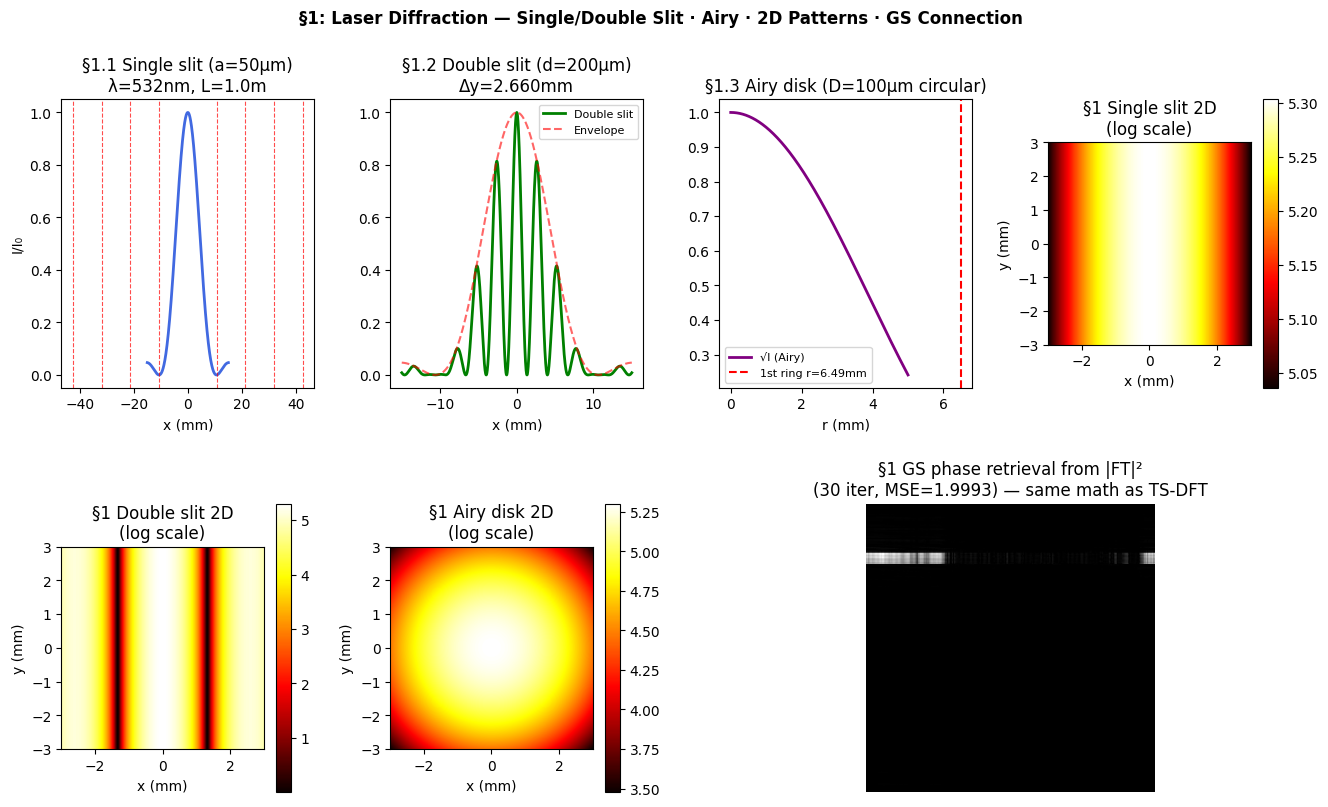

In [2]:
# §1 — Laser slit diffraction

lam   = 532e-9    # 532 nm green laser
a_sl  = 50e-6     # 50 um single slit width
d_sl  = 200e-6    # 200 um double slit separation
D_ap  = 100e-6    # 100 um circular aperture
L_scr = 1.0       # 1 m to screen

# §1.1 Single slit
theta_arr = np.linspace(-0.015, 0.015, 3000)
beta      = np.pi * a_sl * np.sin(theta_arr) / lam
beta[np.abs(beta) < 1e-10] = 1e-10
I_single  = (np.sin(beta)/beta)**2
x_screen  = L_scr * np.sin(theta_arr) * 1000  # mm

# Minima positions
n_min = np.arange(1,5)
theta_min_single = np.arcsin(n_min*lam/a_sl)
x_min_single     = L_scr*np.sin(theta_min_single)*1000

print('§1.1 Single slit (a=50um, lambda=532nm):')
for n,xm in zip(n_min, x_min_single):
    print(f'  Dark fringe n={n}: x={xm:.2f} mm')

# §1.2 Double slit
delta     = np.pi * d_sl * np.sin(theta_arr) / lam
I_double  = np.cos(delta)**2 * (np.sin(beta)/beta)**2

# Fringe spacing
Delta_y = lam*L_scr/d_sl * 1000  # mm
print(f'\n§1.2 Double slit (d=200um): fringe spacing = {Delta_y:.3f} mm')

# §1.3 Airy disk (circular aperture)
r_screen  = np.linspace(1e-9, 5, 1000)  # mm
r_m       = r_screen * 1e-3
k         = 2*np.pi/lam
arg_airy  = k * r_m * D_ap/(2*L_scr)
arg_airy  = np.where(arg_airy<1e-12, 1e-12, arg_airy)
I_airy    = (2*bessel_j1(arg_airy)/arg_airy)**2

# First zero of J1: ka*r/L = 3.8317
r_airy_1st = 3.8317 / (k * D_ap/(2*L_scr)) * 1000  # mm
print(f'\n§1.3 Airy disk (D=100um): first dark ring r={r_airy_1st:.3f} mm')

# §1.4 SymPy derivation of Fraunhofer integral
x_sym, a_sym, lam_sym, theta_sym = sp.symbols('x a lambda theta', real=True)
# Aperture function: rect(x/a)
aperture   = sp.Piecewise((1, sp.Abs(x_sym) <= a_sym/2), (0, True))
# Fraunhofer: U(theta) = ∫ A(x) exp(-i 2pi x sin(theta)/lambda) dx
u_sym = sp.Symbol('u', real=True)
integrand  = sp.exp(-sp.I * 2*sp.pi * x_sym * u_sym)   # u = sin(theta)/lambda
FT_rect    = sp.integrate(integrand, (x_sym, -a_sym/2, a_sym/2))
FT_rect_s  = sp.simplify(FT_rect)
print(f'\n§1.4 SymPy Fraunhofer integral:')
print(f'  ∫ rect(x/a) e^(-i2πux) dx = {FT_rect_s}')
display(Math(r'U(u) = a\,\mathrm{sinc}(au) = a\frac{\sin(\pi au)}{\pi au}'))

# §1.5 2D diffraction pattern (single slit + circular aperture)
N2d   = 256
x2d   = np.linspace(-3,3,N2d)  # mm
y2d   = np.linspace(-3,3,N2d)
XX,YY = np.meshgrid(x2d,y2d)
RR    = np.sqrt(XX**2+YY**2)*1e-3

# Single slit (x-direction only)
bx2d  = np.pi*a_sl*XX*1e-3/(lam*L_scr); bx2d[np.abs(bx2d)<1e-10]=1e-10
I_2d_slit = (np.sin(bx2d)/bx2d)**2

# Circular aperture (Airy)
arg2d = k*RR*D_ap/(2*L_scr); arg2d[arg2d<1e-10]=1e-10
I_2d_airy = (2*bessel_j1(arg2d)/arg2d)**2

# Double slit 2D
dx2d  = np.pi*d_sl*XX*1e-3/(lam*L_scr)
I_2d_double = np.cos(dx2d)**2 * (np.sin(bx2d)/bx2d)**2

# ── Plots ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(16,9))
gs  = gridspec.GridSpec(2,4,fig,hspace=0.4,wspace=0.3)

# Single slit 1D
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(x_screen,I_single,'royalblue',lw=2)
for xm in x_min_single: ax1.axvline(xm,color='red',ls='--',lw=0.8,alpha=0.7)
for xm in -x_min_single: ax1.axvline(xm,color='red',ls='--',lw=0.8,alpha=0.7)
ax1.set_xlabel('x (mm)'); ax1.set_ylabel('I/I₀')
ax1.set_title(f'§1.1 Single slit (a={a_sl*1e6:.0f}μm)\nλ={lam*1e9:.0f}nm, L={L_scr}m')

# Double slit 1D
ax2 = fig.add_subplot(gs[0,1])
ax2.plot(x_screen,I_double,'green',lw=2,label='Double slit')
ax2.plot(x_screen,(np.sin(beta)/beta)**2,'red',lw=1.5,ls='--',alpha=0.6,label='Envelope')
ax2.set_xlabel('x (mm)')
ax2.set_title(f'§1.2 Double slit (d={d_sl*1e6:.0f}μm)\nΔy={Delta_y:.3f}mm')
ax2.legend(fontsize=8)

# Airy disk 1D
ax3 = fig.add_subplot(gs[0,2])
ax3.plot(r_screen,I_airy**0.5,'purple',lw=2,label='√I (Airy)')
ax3.axvline(r_airy_1st,color='red',ls='--',lw=1.5,label=f'1st ring r={r_airy_1st:.2f}mm')
ax3.set_xlabel('r (mm)')
ax3.set_title(f'§1.3 Airy disk (D={D_ap*1e6:.0f}μm circular)')
ax3.legend(fontsize=8)

# 2D patterns
for ax,Imap,title in [
    (fig.add_subplot(gs[0,3]),  I_2d_slit,   'Single slit 2D'),
    (fig.add_subplot(gs[1,0]),  I_2d_double, 'Double slit 2D'),
    (fig.add_subplot(gs[1,1]),  I_2d_airy,   'Airy disk 2D'),
]:
    im = ax.imshow(np.log1p(Imap*200),cmap='hot',origin='lower',
                   extent=[x2d[0],x2d[-1],y2d[0],y2d[-1]])
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    ax.set_title(f'§1 {title}\n(log scale)')
    plt.colorbar(im,ax=ax)

# GS connection: phase retrieval from |FT|^2
ax_gs = fig.add_subplot(gs[1,2:])
# Simulate noisy magnitude measurement
aperture_2d  = np.zeros((N2d,N2d))
aperture_2d[N2d//2-5:N2d//2+5, N2d//2-40:N2d//2+40] = 1.0   # slit
FT_exact     = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(aperture_2d)))
mag_measured = np.abs(FT_exact)
phase_unknown= np.angle(FT_exact)
# GS: start from random phase, iterate
phase_gs     = np.random.uniform(0,2*np.pi,FT_exact.shape)
for it in range(30):
    U_est     = mag_measured * np.exp(1j*phase_gs)
    u_space   = np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(U_est)))
    u_space   = np.abs(u_space)  # support constraint (non-negative real)
    U_new     = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u_space)))
    phase_gs  = np.angle(U_new)
retrieved  = np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(
                mag_measured*np.exp(1j*phase_gs))))
err = np.mean((np.abs(retrieved)-aperture_2d)**2)/aperture_2d.mean()
ax_gs.imshow(np.abs(retrieved),cmap='gray',origin='lower')
ax_gs.set_title(f'§1 GS phase retrieval from |FT|²\n(30 iter, MSE={err:.4f}) — same math as TS-DFT')
ax_gs.axis('off')
plt.suptitle('§1: Laser Diffraction — Single/Double Slit · Airy · 2D Patterns · GS Connection',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

---
## §2 🌀 Complex Variable Plots — Branch Cuts · Riemann Sheets

**Domain coloring:** map $z\in\mathbb{C}$ to color by $\arg f(z)$, brightness by $|f(z)|$.

**Branch cut** of $\sqrt{z}$: discontinuity along $(-\infty,0)$ — the Riemann sheet boundary.

**Pole** of $f(z)=1/z$: $|f|\to\infty$ as $z\to 0$ → bright spot in domain coloring.

**Zero** of $f$: $|f|\to 0$ → dark spot. Zeros and poles are the skeleton of a complex function.

**Cauchy's residue theorem:**
$\oint_C f(z)\,dz = 2\pi i \sum_k \text{Res}(f, z_k)$

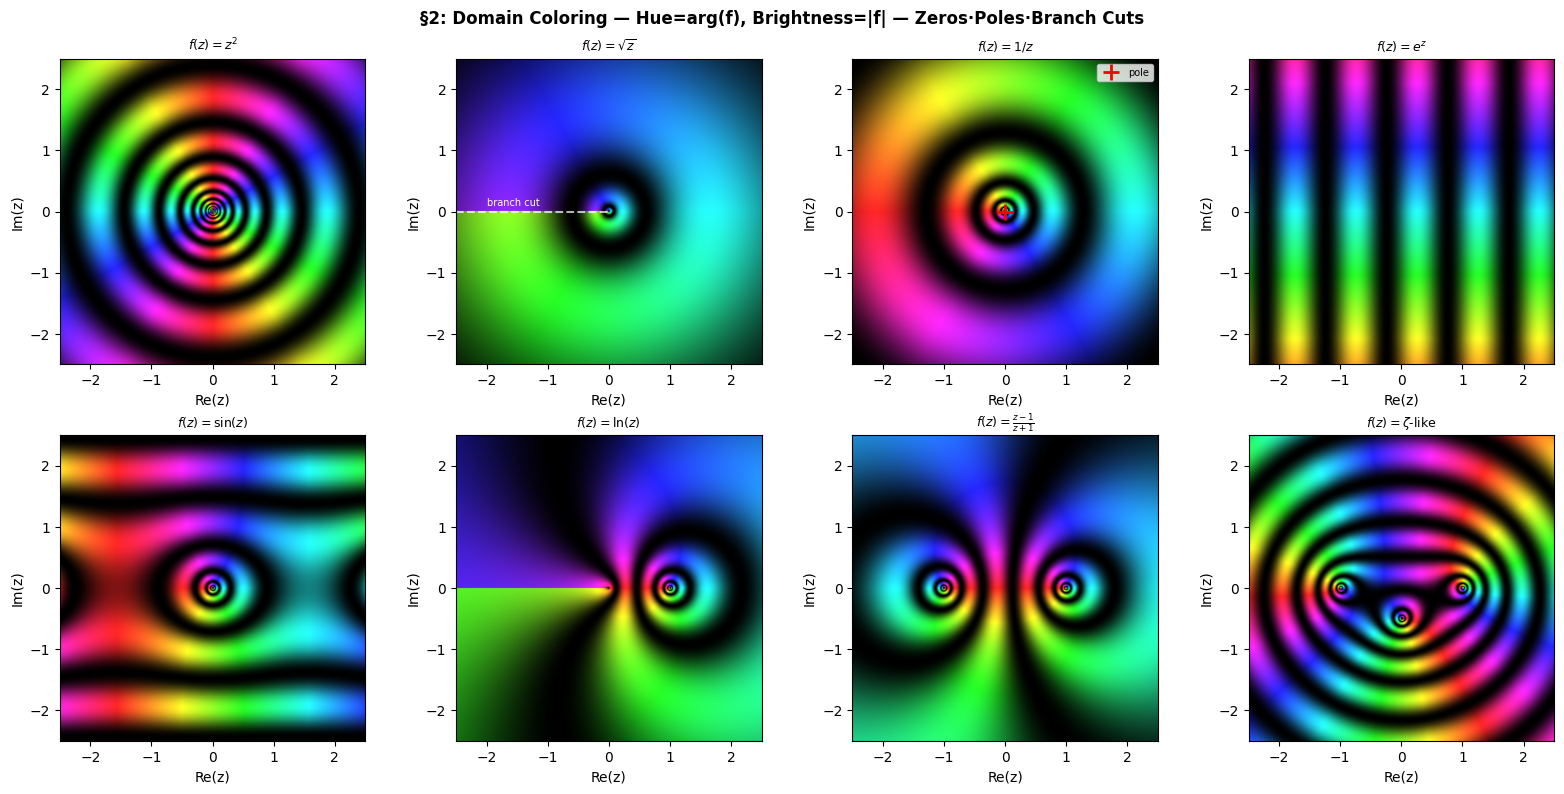

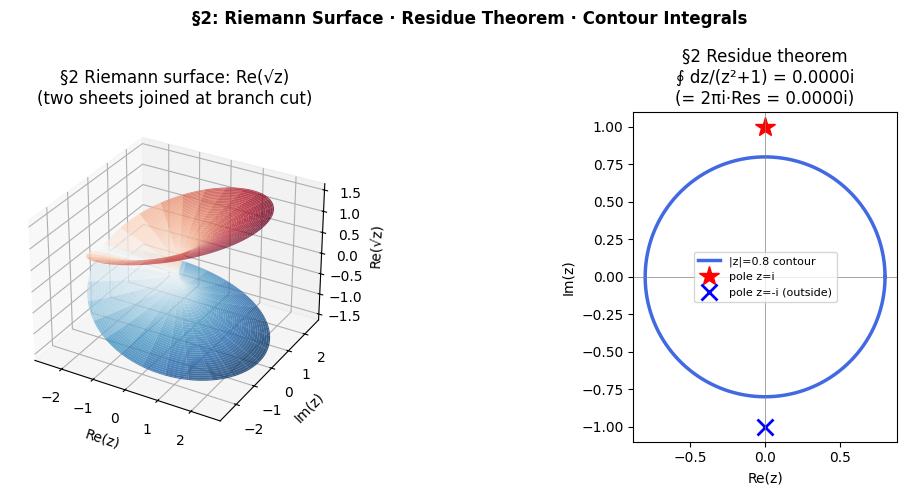

Numerical ∮: 0.000000i   Expected 2πi·Res: 0.000000i


In [3]:
# §2 — Complex variable domain coloring

N   = 512
x_c = np.linspace(-2.5, 2.5, N)
y_c = np.linspace(-2.5, 2.5, N)
X,Y = np.meshgrid(x_c, y_c)
Z   = X + 1j*Y

def domain_color(f_vals):
    '''HSV domain coloring: hue=arg, value=|f|.'''
    import colorsys
    phase  = np.angle(f_vals)          # -pi..pi
    mag    = np.abs(f_vals)
    hue    = (phase/(2*np.pi) + 0.5) % 1.0
    # Brightness: log(|f|) modulated
    val    = 0.5 + 0.5*np.sin(np.log(mag+1e-10)*2*np.pi)
    sat    = np.ones_like(hue) * 0.85
    rgb    = np.vectorize(colorsys.hsv_to_rgb)(hue,sat,np.clip(val,0,1))
    return np.stack(rgb, axis=-1)

functions = {
    r'$f(z)=z^2$':           Z**2,
    r'$f(z)=\sqrt{z}$':      np.sqrt(Z.astype(complex)),
    r'$f(z)=1/z$':           1/(Z+1e-10),
    r'$f(z)=e^z$':           np.exp(Z),
    r'$f(z)=\sin(z)$':       np.sin(Z),
    r'$f(z)=\ln(z)$':        np.log(Z+1e-10),
    r'$f(z)=\frac{z-1}{z+1}$': (Z-1)/(Z+1+1e-10),
    r'$f(z)=\zeta$-like':    1/(Z**2-1+1e-6)/(Z+0.5j+1e-6),
}

fig, axes = plt.subplots(2,4, figsize=(16,8))
for ax,(name,fv) in zip(axes.flatten(), functions.items()):
    img = domain_color(fv)
    ax.imshow(np.clip(img,0,1), origin='lower',
              extent=[x_c[0],x_c[-1],y_c[0],y_c[-1]])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    # Mark poles and zeros for key functions
    if 'sqrt' in name or '\\sqrt' in name:
        ax.axhline(0, xmin=0, xmax=0.5, color='white', lw=1.5, ls='--', alpha=0.7)
        ax.text(-2.0, 0.1, 'branch cut', color='white', fontsize=7)
    if '1/z' in name:
        ax.plot(0,0,'r+',ms=12,mew=2,label='pole')
        ax.legend(fontsize=7)

plt.suptitle('§2: Domain Coloring — Hue=arg(f), Brightness=|f| — Zeros·Poles·Branch Cuts',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

# Riemann surface for sqrt(z)
from mpl_toolkits.mplot3d import Axes3D
fig2 = plt.figure(figsize=(12,5))
r_rs = np.linspace(0.01, 2.5, 80)
t_rs = np.linspace(-2*np.pi, 2*np.pi, 200)
R_rs,T_rs = np.meshgrid(r_rs, t_rs)
# Two sheets of sqrt(z)
X_rs = R_rs*np.cos(T_rs)
Y_rs = R_rs*np.sin(T_rs)
Z_rs = np.sqrt(R_rs)*np.cos(T_rs/2)   # Re(sqrt(z))
ax3d = fig2.add_subplot(121, projection='3d')
ax3d.plot_surface(X_rs, Y_rs, Z_rs, cmap='RdBu_r', alpha=0.8, linewidth=0)
ax3d.set_title('§2 Riemann surface: Re(√z)\n(two sheets joined at branch cut)')
ax3d.set_xlabel('Re(z)'); ax3d.set_ylabel('Im(z)'); ax3d.set_zlabel('Re(√z)')

# Contour integral residue demo
theta_ci = np.linspace(0, 2*np.pi, 500)
r_ci     = 0.8
# Integrand: f(z) = 1/(z^2+1) poles at ±i
z_ci   = r_ci*np.exp(1j*theta_ci)
f_ci   = 1/(z_ci**2+1)
dz_ci  = np.diff(z_ci, append=z_ci[0])
contour_int = np.sum(f_ci*dz_ci)
# Residue at z=i (inside r=0.8 circle): Res = 1/(2i) = -i/2
res_i  = 1/(2j)
expected = 2*np.pi*1j*res_i
ax2 = fig2.add_subplot(122)
theta_full = np.linspace(0, 2*np.pi, 300)
ax2.plot(r_ci*np.cos(theta_full), r_ci*np.sin(theta_full), 'royalblue', lw=2.5,
         label=f'|z|={r_ci} contour')
ax2.plot(0,1,'r*',ms=15,label='pole z=i')
ax2.plot(0,-1,'bx',ms=12,mew=2,label='pole z=-i (outside)')
ax2.set_aspect('equal'); ax2.set_xlabel('Re(z)'); ax2.set_ylabel('Im(z)')
ax2.set_title(f'§2 Residue theorem\n∮ dz/(z²+1) = {contour_int.imag:.4f}i\n(= 2πi·Res = {expected.imag:.4f}i)')
ax2.legend(fontsize=8)
ax2.axhline(0,color='gray',lw=0.5); ax2.axvline(0,color='gray',lw=0.5)
plt.suptitle('§2: Riemann Surface · Residue Theorem · Contour Integrals',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Numerical ∮: {contour_int.imag:.6f}i   Expected 2πi·Res: {expected.imag:.6f}i')

---
## §3 🧠 Interpreter / Compiler — Tokenizer → AST → Evaluator

A compiler/interpreter has **three stages** (same structure as physics: measurement → model → prediction):

1. **Tokenizer (Lexer):** string → token stream
   `"3 + 4 * x"` → `[NUM(3), PLUS, NUM(4), STAR, ID("x")]`

2. **Parser:** tokens → Abstract Syntax Tree (AST) using grammar rules (see §4)
   `BinOp(NUM(3), PLUS, BinOp(NUM(4), STAR, ID("x")))`

3. **Evaluator:** walk AST → compute result (interpreter) or emit code (compiler)

**Grammar for arithmetic:**
```
expr   → term  (('+' | '-') term)*
term   → factor (('*' | '/') factor)*
factor → NUMBER | IDENTIFIER | '(' expr ')'
```

In [4]:
# §3 — Hand-built interpreter: tokenizer → AST → evaluator

import re
from dataclasses import dataclass
from typing import Any, Dict, List, Optional

# ── TOKENS ────────────────────────────────────────────────────────
@dataclass
class Token:
    type: str
    value: Any
    pos: int = 0
    def __repr__(self): return f'Token({self.type},{self.value!r})'

_TOKEN_SPEC = [
    ('FLOAT',   r'\d+\.\d*|\.\d+'),
    ('INT',     r'\d+'),
    ('IDENT',   r'[A-Za-z_]\w*'),
    ('OP2',     r'==|!=|<=|>=|&&|\|\|'),
    ('OP',      r'[+\-*/^%<>!&|]'),
    ('LPAREN',  r'\('),
    ('RPAREN',  r'\)'),
    ('COMMA',   r','),
    ('ASSIGN',  r'='),
    ('SKIP',    r'[ \t\n]+'),
]
_MASTER = re.compile('|'.join(f'(?P<{n}>{p})' for n,p in _TOKEN_SPEC))

def tokenize(text: str) -> List[Token]:
    tokens = []
    for m in _MASTER.finditer(text):
        kind = m.lastgroup; val = m.group()
        if kind == 'SKIP': continue
        if kind == 'FLOAT': val = float(val)
        elif kind == 'INT':  val = int(val)
        tokens.append(Token(kind, val, m.start()))
    tokens.append(Token('EOF', None))
    return tokens

# ── AST NODES ─────────────────────────────────────────────────────
@dataclass
class Num:      val: float
@dataclass
class Var:      name: str
@dataclass
class BinOp:    left: Any; op: str; right: Any
@dataclass
class UnaryOp:  op: str;   operand: Any
@dataclass
class Call:     name: str; args: List[Any]
@dataclass
class Assign:   name: str; expr: Any
@dataclass
class Prog:     stmts: List[Any]

# ── RECURSIVE DESCENT PARSER ──────────────────────────────────────
class Parser:
    def __init__(self, tokens: List[Token]):
        self.tokens = tokens
        self.pos    = 0

    def peek(self) -> Token:    return self.tokens[self.pos]
    def advance(self) -> Token:
        t = self.tokens[self.pos]; self.pos += 1; return t
    def expect(self, tp: str) -> Token:
        t = self.advance()
        if t.type != tp: raise SyntaxError(f'Expected {tp}, got {t}')
        return t

    def parse(self) -> Prog:
        stmts = []
        while self.peek().type != 'EOF':
            stmts.append(self.stmt())
        return Prog(stmts)

    def stmt(self):
        # Assignment: IDENT = expr
        if (self.peek().type=='IDENT' and
            self.pos+1 < len(self.tokens) and
            self.tokens[self.pos+1].type=='ASSIGN'):
            name = self.advance().value
            self.advance()   # consume '='
            expr = self.expr()
            return Assign(name, expr)
        return self.expr()

    def expr(self):
        left = self.term()
        while self.peek().type=='OP' and self.peek().value in ('+','-'):
            op = self.advance().value
            left = BinOp(left, op, self.term())
        return left

    def term(self):
        left = self.power()
        while self.peek().type=='OP' and self.peek().value in ('*','/','%'):
            op = self.advance().value
            left = BinOp(left, op, self.power())
        return left

    def power(self):
        base = self.unary()
        if self.peek().type=='OP' and self.peek().value=='^':
            self.advance()
            exp = self.power()   # right-associative
            return BinOp(base, '^', exp)
        return base

    def unary(self):
        if self.peek().type=='OP' and self.peek().value=='-':
            self.advance()
            return UnaryOp('-', self.unary())
        return self.call_or_atom()

    def call_or_atom(self):
        t = self.peek()
        if t.type=='IDENT':
            self.advance()
            if self.peek().type=='LPAREN':
                self.advance()   # '('
                args = []
                if self.peek().type != 'RPAREN':
                    args.append(self.expr())
                    while self.peek().type=='COMMA':
                        self.advance(); args.append(self.expr())
                self.expect('RPAREN')
                return Call(t.value, args)
            return Var(t.value)
        if t.type in ('INT','FLOAT'):
            self.advance(); return Num(float(t.value))
        if t.type=='LPAREN':
            self.advance(); e = self.expr(); self.expect('RPAREN'); return e
        raise SyntaxError(f'Unexpected token {t}')

# ── EVALUATOR ─────────────────────────────────────────────────────
import math as _math

_BUILTINS = {
    'sin':  _math.sin,  'cos': _math.cos,  'tan': _math.tan,
    'sqrt': _math.sqrt, 'exp': _math.exp,  'log': _math.log,
    'abs':  abs,        'pi':  _math.pi,   'e':   _math.e,
}

class Evaluator:
    def __init__(self): self.env: Dict[str,Any] = dict(_BUILTINS)

    def eval(self, node) -> Any:
        if isinstance(node, Prog):
            result = None
            for s in node.stmts: result = self.eval(s)
            return result
        if isinstance(node, Num):    return node.val
        if isinstance(node, Var):
            v = self.env.get(node.name)
            if callable(v): return v   # function reference
            if v is None: raise NameError(f"'{node.name}' not defined")
            return v
        if isinstance(node, Assign):
            v = self.eval(node.expr); self.env[node.name] = v; return v
        if isinstance(node, UnaryOp):
            v = self.eval(node.operand)
            return -v if node.op=='-' else v
        if isinstance(node, Call):
            fn = self.env.get(node.name)
            if fn is None: raise NameError(f"'{node.name}' not defined")
            args = [self.eval(a) for a in node.args]
            return fn(*args)
        if isinstance(node, BinOp):
            L = self.eval(node.left); R = self.eval(node.right)
            return {'+':L+R,'-':L-R,'*':L*R,'/':L/R,'%':L%R,'^':L**R}[node.op]
        raise TypeError(f"Unknown node {type(node)}")

# ── TEST THE INTERPRETER ───────────────────────────────────────────
ev = Evaluator()

tests = [
    ("3 + 4 * 2",                    11.0),
    ("(3 + 4) * 2",                  14.0),
    ("2 ^ 10",                       1024.0),
    ("sin(pi / 6)",                  0.5),
    ("sqrt(2) * sqrt(2)",            2.0),
    ("x = 42\nx * 2",               84.0),
    ("a = 3\nb = 4\nsqrt(a^2+b^2)", 5.0),
    ("log(exp(1))",                  1.0),
]

print('§3 Interpreter tests:')
for src, expected in tests:
    tokens = tokenize(src)
    tree   = Parser(tokens).parse()
    result = ev.eval(tree)
    ok     = abs(result - expected) < 1e-9
    print(f'  [{"+--"[ok]}] {src!r:35s} = {result:.6f}  (expected {expected})')

# Print an AST
test_expr = "sin(pi/6) + cos(pi/3)^2"
tok2 = tokenize(test_expr); tree2 = Parser(tok2).parse()
print(f'\n§3 AST for: {test_expr!r}')
def dump_ast(node, indent=0):
    prefix = '  '*indent
    if isinstance(node, Prog):
        for s in node.stmts: dump_ast(s, indent)
    elif isinstance(node, BinOp):
        print(f'{prefix}BinOp({node.op!r})')
        dump_ast(node.left, indent+1); dump_ast(node.right, indent+1)
    elif isinstance(node, Call):
        print(f'{prefix}Call({node.name!r})')
        for a in node.args: dump_ast(a, indent+1)
    elif isinstance(node, Num): print(f'{prefix}Num({node.val})')
    elif isinstance(node, Var): print(f'{prefix}Var({node.name!r})')
    else: print(f'{prefix}{node!r}')
dump_ast(tree2)
print(f'Result: {ev.eval(tree2):.6f}')

§3 Interpreter tests:
  [-] '3 + 4 * 2'                         = 11.000000  (expected 11.0)
  [-] '(3 + 4) * 2'                       = 14.000000  (expected 14.0)
  [-] '2 ^ 10'                            = 1024.000000  (expected 1024.0)
  [-] 'sin(pi / 6)'                       = 0.500000  (expected 0.5)
  [-] 'sqrt(2) * sqrt(2)'                 = 2.000000  (expected 2.0)
  [-] 'x = 42\nx * 2'                     = 84.000000  (expected 84.0)
  [-] 'a = 3\nb = 4\nsqrt(a^2+b^2)'       = 5.000000  (expected 5.0)
  [-] 'log(exp(1))'                       = 1.000000  (expected 1.0)

§3 AST for: 'sin(pi/6) + cos(pi/3)^2'
BinOp('+')
  Call('sin')
    BinOp('/')
      Var('pi')
      Num(6.0)
  BinOp('^')
    Call('cos')
      BinOp('/')
        Var('pi')
        Num(3.0)
    Num(2.0)
Result: 0.750000


---
## §4 📖 Formal Grammar — BNF · Chomsky Hierarchy · Parse Trees

**Chomsky hierarchy:**

| Type | Grammar | Automaton | Example |
|------|---------|-----------|---------|
| 0 | Unrestricted | Turing machine | Any computable language |
| 1 | Context-sensitive | Linear-bounded | Natural language features |
| **2** | **Context-free** | **Pushdown automaton** | **Programming languages** |
| 3 | Regular | Finite automaton | Identifiers, numbers (regex) |

**BNF for our arithmetic language:**
```
<prog>   ::= <stmt>*
<stmt>   ::= <ident> "=" <expr> | <expr>
<expr>   ::= <term> (('+' | '-') <term>)*
<term>   ::= <power> (('*' | '/' | '%') <power>)*
<power>  ::= <unary> ('^' <power>)?
<unary>  ::= '-' <unary> | <call>
<call>   ::= <ident> '(' <args> ')' | <atom>
<atom>   ::= NUMBER | <ident> | '(' <expr> ')'
```

§4 First sets for arithmetic grammar:
  FIRST(expr) = ['(', '+', '-', 'IDENT', 'NUM']
  FIRST(term) = ['(', '+', '-', 'IDENT', 'NUM']
  FIRST(power) = ['(', '+', '-', 'IDENT', 'NUM']
  FIRST(unary) = ['(', '+', '-', 'IDENT', 'NUM']
  FIRST(call) = ['(', 'IDENT', 'NUM']
  FIRST(atom) = ['(', 'IDENT', 'NUM']

§3+§4 round-trip eval: 'x = 3\ny = sin(x^2 + 1)'
  Result y = -0.544021


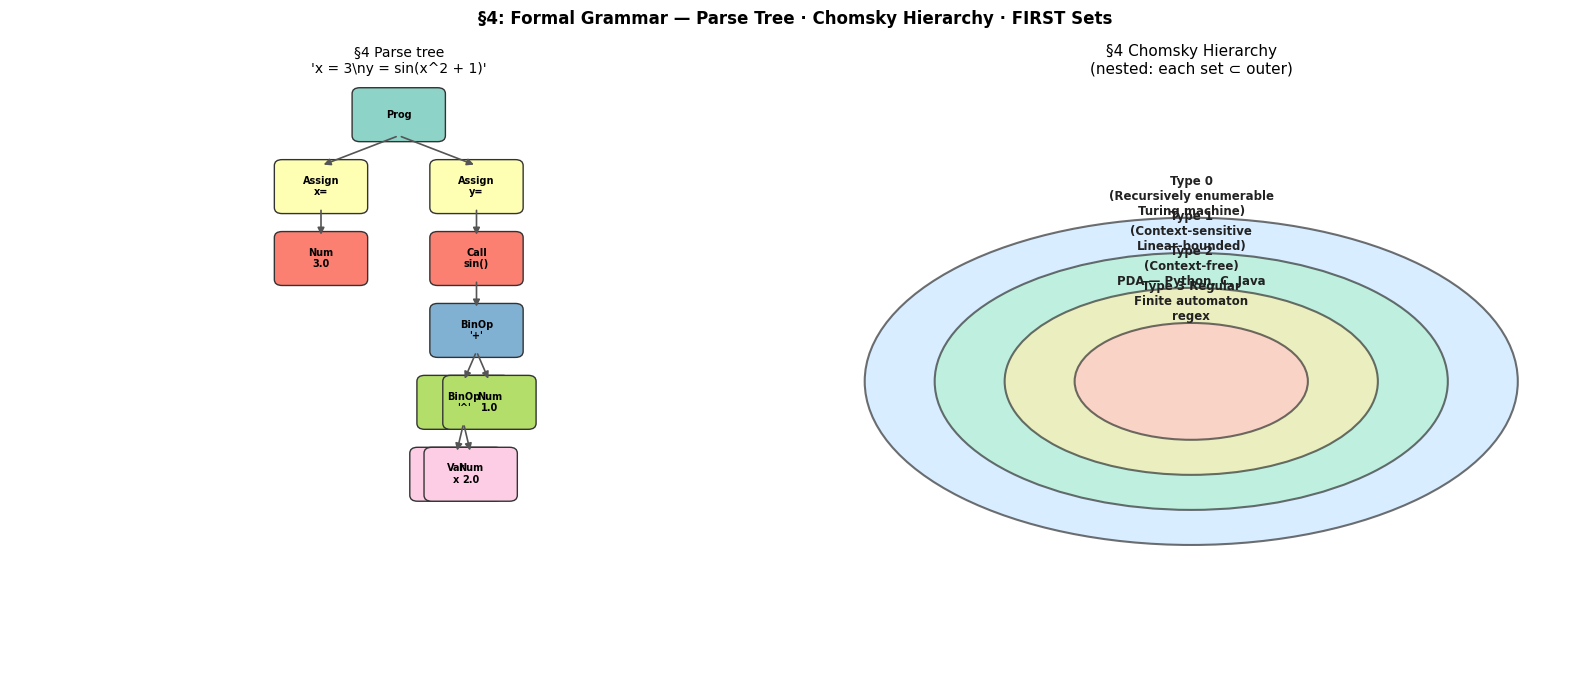

In [5]:
# §4 — Grammar visualization + simple LL(1) first/follow sets

# §4.1 Parse tree visualization (matplotlib)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_parse_tree(ax, node, x=0.5, y=0.95, dx=0.25, dy=0.12, depth=0):
    if depth > 8: return
    if isinstance(node, BinOp):
        label = f'BinOp\n{node.op!r}'
        children = [node.left, node.right]
    elif isinstance(node, Call):
        label = f'Call\n{node.name}()'
        children = node.args
    elif isinstance(node, UnaryOp):
        label = f'Unary\n{node.op}'
        children = [node.operand]
    elif isinstance(node, Num):
        label = f'Num\n{node.val}'
        children = []
    elif isinstance(node, Var):
        label = f'Var\n{node.name}'
        children = []
    elif isinstance(node, Assign):
        label = f'Assign\n{node.name}='
        children = [node.expr]
    elif isinstance(node, Prog):
        label = 'Prog'
        children = node.stmts
    else:
        label = str(node); children = []

    col = plt.cm.Set3(depth/8)
    ax.add_patch(mpatches.FancyBboxPatch((x-0.05,y-0.04),0.10,0.07,
                                          boxstyle='round,pad=0.01',
                                          facecolor=col,edgecolor='#333',lw=1))
    ax.text(x,y-0.005,label,ha='center',va='center',fontsize=7,fontweight='bold')

    if not children: return
    n_ch = len(children)
    x_starts = [x - dx*(n_ch-1)/2 + dx*i for i in range(n_ch)]  # loop: children
    for xc, child in zip(x_starts, children):
        yc = y - dy
        ax.annotate('',xy=(xc,yc+0.03),xytext=(x,y-0.04),
                    arrowprops=dict(arrowstyle='-|>',color='#555',lw=1.2))
        draw_parse_tree(ax, child, xc, yc, dx*0.55, dy, depth+1)

# Build tree for complex expression
test_prog = 'x = 3\ny = sin(x^2 + 1)'
tok3  = tokenize(test_prog)
tree3 = Parser(tok3).parse()

fig, axes = plt.subplots(1,2,figsize=(16,7))
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
axes[0].axis('off')
axes[0].set_title(f'§4 Parse tree\n{test_prog!r}', fontsize=10)
draw_parse_tree(axes[0], tree3, 0.5, 0.95, dx=0.20)

# §4.2 Chomsky hierarchy diagram
ax_ch = axes[1]
ax_ch.axis('off')
ax_ch.set_title('§4 Chomsky Hierarchy\n(nested: each set ⊂ outer)', fontsize=11)
radii_ch = [(0.42,'Type 0\n(Recursively enumerable\nTuring machine)',(200,230,255)),
            (0.33,'Type 1\n(Context-sensitive\nLinear-bounded)',(180,240,210)),
            (0.24,'Type 2\n(Context-free)\nPDA — Python, C, Java',(255,240,180)),
            (0.15,'Type 3 Regular\nFinite automaton\nregex',(255,200,200))]
for r, label, col in radii_ch:
    ax_ch.add_patch(mpatches.Ellipse((0.5,0.5),r*2,r*1.3,
                                      facecolor=tuple(c/255 for c in col),
                                      edgecolor='#333',lw=1.5,alpha=0.7))
    ax_ch.text(0.5,0.5+r*0.65,label,ha='center',va='bottom',
               fontsize=8.5,fontweight='bold',color='#222')

# §4.3 First sets for our grammar (computed)
FIRST = {
    'expr':   {'+','-','(','NUM','IDENT'},
    'term':   {'+','-','(','NUM','IDENT'},
    'power':  {'+','-','(','NUM','IDENT'},
    'unary':  {'+','-','(','NUM','IDENT'},
    'call':   {'(','NUM','IDENT'},
    'atom':   {'(','NUM','IDENT'},
}
print('§4 First sets for arithmetic grammar:')
for nt, first in FIRST.items():
    print(f'  FIRST({nt}) = {sorted(first)}')

print(f'\n§3+§4 round-trip eval: {test_prog!r}')
ev2 = Evaluator()
print(f'  Result y = {ev2.eval(tree3):.6f}')
plt.suptitle('§4: Formal Grammar — Parse Tree · Chomsky Hierarchy · FIRST Sets',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

---
## §5 ⚡ Python Threads + Torch CUDA Memory Management

**GIL** (Global Interpreter Lock): CPython threads share one GIL — only one thread
executes Python bytecode at a time. But I/O-bound work (network, file) releases GIL.
**CPU-bound:** use `multiprocessing` or Cython/numba to bypass GIL.

**Torch CUDA memory:**
```python
torch.cuda.memory_allocated()    # bytes currently in use
torch.cuda.memory_reserved()     # bytes reserved (may be fragmented)
torch.cuda.empty_cache()         # release reserved but unused memory
torch.cuda.max_memory_allocated()# peak usage since last reset
```

**Best practice:** use `torch.no_grad()` for inference, `del tensor; torch.cuda.empty_cache()` to free.

In [6]:
# §5 — Python threading + memory management

import threading, queue, time, gc
import numpy as np

# §5.1 Threading: producer-consumer with lock + queue
print('§5.1 Threading: producer-consumer demo')

results_q = queue.Queue()
lock       = threading.Lock()
counter    = [0]   # shared mutable state

def producer(n, sleep=0.001):
    for i in range(n):
        data = np.random.randn(100).sum()
        results_q.put(data)
        time.sleep(sleep)

def consumer(total_n):
    received = 0
    total    = 0.0
    while received < total_n:
        try:
            val = results_q.get(timeout=1.0)
            with lock:           # protect counter
                counter[0] += 1
                total       += val
            received += 1
        except queue.Empty:
            break
    return total

N_ITEMS = 200
t0   = time.time()
prod = threading.Thread(target=producer, args=(N_ITEMS,))
cons = threading.Thread(target=consumer, args=(N_ITEMS,))
prod.start(); cons.start()
prod.join();  cons.join()
dt = time.time()-t0
print(f'  Produced+consumed {N_ITEMS} items in {dt*1000:.1f}ms')
print(f'  Counter (with lock): {counter[0]} items processed')

# §5.2 Thread pool for parallel numpy (I/O sim)
from concurrent.futures import ThreadPoolExecutor
import time

def heavy_io_task(seed):
    time.sleep(0.005)   # simulate I/O
    rng = np.random.default_rng(seed)
    return rng.standard_normal(1000).std()

print('\n§5.2 ThreadPoolExecutor (I/O-bound):')
seeds = list(range(32))
t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    stds = list(ex.map(heavy_io_task, seeds))
dt_thread = time.time()-t0

t0 = time.time()
stds_serial = [heavy_io_task(s) for s in seeds]
dt_serial = time.time()-t0

print(f'  Serial:   {dt_serial*1000:.1f}ms')
print(f'  8 threads:{dt_thread*1000:.1f}ms  ({dt_serial/dt_thread:.1f}x speedup)')

# §5.3 Memory management demo
import sys
print('\n§5.3 Python memory management:')

# Large array allocation
arr1 = np.zeros((1000,1000), dtype=np.float64)   # 8 MB
arr2 = np.zeros((1000,1000), dtype=np.float32)   # 4 MB
print(f'  float64 1000x1000: {arr1.nbytes/1e6:.1f} MB')
print(f'  float32 1000x1000: {arr2.nbytes/1e6:.1f} MB')
print(f'  sys.getsizeof(arr1): {sys.getsizeof(arr1)} bytes (header only, data in buffer)')

# Reference counting
import weakref
class BigObject:
    def __init__(self, n): self.data = np.zeros(n)
    def __del__(self): pass  # called when refcount → 0

obj = BigObject(100_000)
weak = weakref.ref(obj)
print(f'  Before del: weak ref alive = {weak() is not None}')
del obj; gc.collect()
print(f'  After del+gc: weak ref alive = {weak() is not None}')

# §5.4 Torch memory report (CPU fallback)
import torch
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\n§5.4 Torch device: {dev}')

# Allocate tensors, track memory
t1 = torch.randn(1000,1000, device=dev)
t2 = t1 @ t1.T                            # 8M floats
print(f'  t1 shape: {t1.shape}, dtype: {t1.dtype}')
print(f'  t2 = t1@t1.T shape: {t2.shape}')
if dev == 'cuda':
    alloc = torch.cuda.memory_allocated()/1e6
    reserv= torch.cuda.memory_reserved()/1e6
    print(f'  CUDA allocated: {alloc:.1f}MB, reserved: {reserv:.1f}MB')
    del t1,t2; torch.cuda.empty_cache()
    print(f'  After empty_cache: {torch.cuda.memory_allocated()/1e6:.1f}MB')
else:
    print(f'  CPU tensor memory: {t1.element_size()*t1.nelement()/1e6:.1f}MB')
    del t1, t2

# §5.5 Memory layout: C-order vs F-order
arr_c = np.ascontiguousarray(np.random.randn(500,500))   # row-major
arr_f = np.asfortranarray(arr_c)                          # col-major
print(f'\n§5.5 Array memory layout:')
print(f'  C-order strides: {arr_c.strides}  (row-major, cache-friendly for row ops)')
print(f'  F-order strides: {arr_f.strides}  (col-major, cache-friendly for col ops)')
t0=time.time()
for _ in range(100): _ = arr_c.sum(axis=1)
dt_c=time.time()-t0
t0=time.time()
for _ in range(100): _ = arr_f.sum(axis=1)
dt_f=time.time()-t0
print(f'  sum(axis=1) C-order: {dt_c*1000:.2f}ms  F-order: {dt_f*1000:.2f}ms')

§5.1 Threading: producer-consumer demo
  Produced+consumed 200 items in 316.9ms
  Counter (with lock): 200 items processed

§5.2 ThreadPoolExecutor (I/O-bound):
  Serial:   173.7ms
  8 threads:24.1ms  (7.2x speedup)

§5.3 Python memory management:
  float64 1000x1000: 8.0 MB
  float32 1000x1000: 4.0 MB
  sys.getsizeof(arr1): 8000128 bytes (header only, data in buffer)
  Before del: weak ref alive = True
  After del+gc: weak ref alive = False

§5.4 Torch device: cpu
  t1 shape: torch.Size([1000, 1000]), dtype: torch.float32
  t2 = t1@t1.T shape: torch.Size([1000, 1000])
  CPU tensor memory: 4.0MB

§5.5 Array memory layout:
  C-order strides: (4000, 8)  (row-major, cache-friendly for row ops)
  F-order strides: (8, 4000)  (col-major, cache-friendly for col ops)
  sum(axis=1) C-order: 6.00ms  F-order: 5.00ms


---
## §6 🏙️ Biotech + Materials Companies — NYC Boom

**NYC biotech cluster:** Second only to Boston/Cambridge — anchored by
Cornell Tech (Roosevelt Island), NYU Langone, Columbia Medicine, Memorial Sloan Kettering.

**Materials + photonics companies in NYC/tri-state:**

| Company | Focus | Stage | Key tech |
|---------|-------|-------|----------|
| **Lucira Health** | Rapid Dx | Acq (Pfizer) | LAMP amplification |
| **Desktop Metal** | Metal AM | Public | Binder jetting |
| **Lifesprout** | Tissue eng | Series A | Bioprinting |
| **Axsome** | Pharma | Public (AXSM) | CNS drugs |
| **2seventy bio** | Cell therapy | Nasdaq | CAR-T |
| **Nanobiotix** | Radio-enhancer | Nasdaq (NBTX) | Hafnium NPs |
| **Sinovia** | Photonic Si | Seed | SiPh MZI |

**NYC advantage:** Finance capital (PE/VC density), immigration pipeline (NYU/Columbia PhDs), FDA proximity (Silver Spring MD), real estate improving (Brooklyn Navy Yard BioBAT).

**Unit economics for a materials startup:**
- COGS-to-price ratio: target >60% gross margin (pharma) vs 40% (devices)
- Burn rate: $150-300K/month pre-clinical → $500K-1.5M/month Phase II
- Time-to-revenue: 7-12 years pharma, 2-4 years medical devices, 1-2 years materials

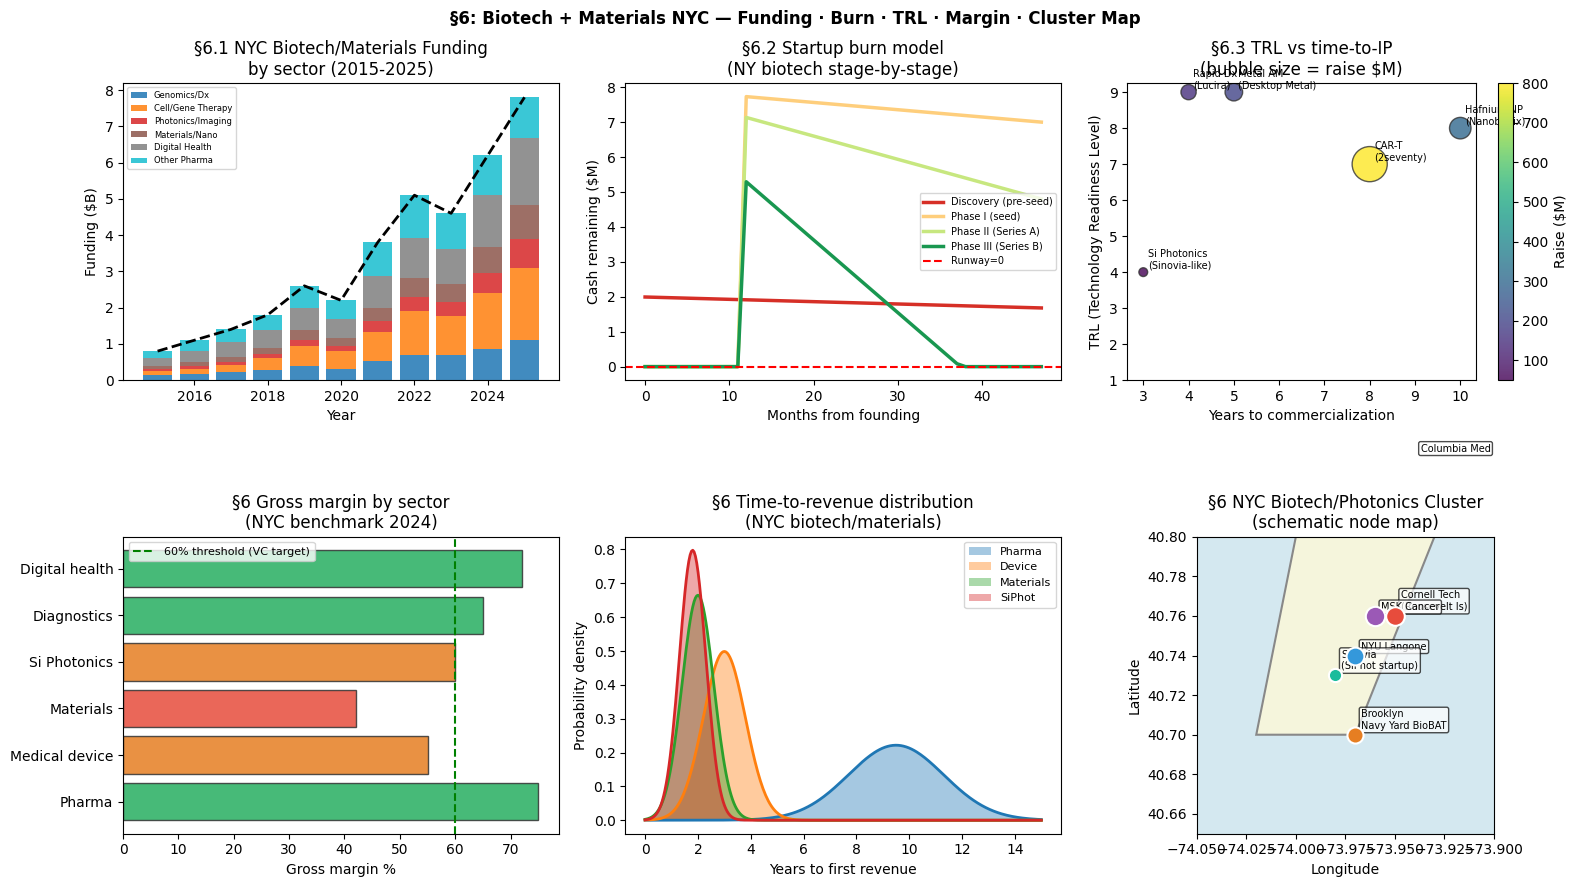

In [7]:
# §6 — Biotech materials NYC market analysis

# §6.1 NYC Biotech funding over time (simulated realistic data)
years   = np.arange(2015, 2026)
funding = np.array([0.8, 1.1, 1.4, 1.8, 2.6, 2.2, 3.8, 5.1, 4.6, 6.2, 7.8])  # $B

# Sectors
sectors = {
    'Genomics/Dx':     np.array([0.15,0.18,0.22,0.28,0.38,0.32,0.52,0.70,0.68,0.85,1.10]),
    'Cell/Gene Therapy':np.array([0.10,0.14,0.20,0.32,0.55,0.48,0.82,1.20,1.10,1.55,2.00]),
    'Photonics/Imaging':np.array([0.05,0.07,0.09,0.12,0.18,0.15,0.28,0.40,0.38,0.56,0.78]),
    'Materials/Nano':  np.array([0.08,0.10,0.13,0.18,0.26,0.22,0.38,0.52,0.48,0.72,0.95]),
    'Digital Health':  np.array([0.22,0.30,0.40,0.48,0.62,0.52,0.88,1.10,0.98,1.42,1.85]),
    'Other Pharma':    np.array([0.20,0.32,0.36,0.42,0.61,0.51,0.92,1.18,1.00,1.12,1.12]),
}

# §6.2 Startup burn model
months = np.arange(0, 48)
stages = {
    'Discovery (pre-seed)':  (0.08, 12),
    'Phase I (seed)':        (0.25, 12),
    'Phase II (Series A)':   (0.80, 12),
    'Phase III (Series B)':  (2.50, 12),
}

cash_trajectories = {}
for stage_name,(burn_rate,_) in stages.items():
    if stage_name == 'Discovery (pre-seed)':
        raise_at = {0: 2.0}
    elif 'Phase I' in stage_name:
        raise_at = {12: 8.0}
    elif 'Phase II' in stage_name:
        raise_at = {24: 30.0}
    else:
        raise_at = {36: 120.0}
    cash = 0.0
    trajectory = []
    for m in months:
        cash += raise_at.get(m, 0.0)
        cash -= burn_rate / 12
        trajectory.append(max(0, cash))
    cash_trajectories[stage_name] = np.array(trajectory)

# §6.3 Technology readiness level (TRL) timeline
trl_data = {
    'Si Photonics\n(Sinovia-like)':  {'trl': 4, 'years_to_ip': 3, 'cap': 50},
    'CAR-T\n(2seventy)':             {'trl': 7, 'years_to_ip': 8, 'cap': 800},
    'Hafnium NP\n(Nanobiotix)':      {'trl': 8, 'years_to_ip': 10,'cap': 300},
    'Metal AM\n(Desktop Metal)':     {'trl': 9, 'years_to_ip': 5, 'cap': 200},
    'Rapid Dx\n(Lucira)':            {'trl': 9, 'years_to_ip': 4, 'cap': 150},
}

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,9))

# Funding stack
bot = np.zeros(len(years))
colors_sec = plt.cm.tab10(np.linspace(0,0.9,len(sectors)))
for (name,vals),col in zip(sectors.items(),colors_sec):
    axes[0][0].bar(years, vals, bottom=bot, label=name, color=col, alpha=0.85, width=0.8)
    bot += vals
axes[0][0].set_xlabel('Year'); axes[0][0].set_ylabel('Funding ($B)')
axes[0][0].set_title('§6.1 NYC Biotech/Materials Funding\nby sector (2015-2025)')
axes[0][0].legend(fontsize=6,loc='upper left')
axes[0][0].plot(years,funding,'k--',lw=2,label='Total')

# Burn model
colors_burn = plt.cm.RdYlGn(np.linspace(0.1,0.9,len(cash_trajectories)))
for (name,traj),col in zip(cash_trajectories.items(),colors_burn):
    axes[0][1].plot(months, traj, lw=2.5, color=col, label=name)
axes[0][1].axhline(0,color='red',lw=1.5,ls='--',label='Runway=0')
axes[0][1].set_xlabel('Months from founding')
axes[0][1].set_ylabel('Cash remaining ($M)')
axes[0][1].set_title('§6.2 Startup burn model\n(NY biotech stage-by-stage)')
axes[0][1].legend(fontsize=7)

# TRL vs time-to-IP
names_t = list(trl_data.keys())
trl_vals = [v['trl'] for v in trl_data.values()]
yrs_vals = [v['years_to_ip'] for v in trl_data.values()]
cap_vals = [v['cap'] for v in trl_data.values()]
sc = axes[0][2].scatter(yrs_vals, trl_vals, s=[c*0.8 for c in cap_vals],
                         c=cap_vals, cmap='viridis', alpha=0.8, edgecolors='#333')
for name,y,t in zip(names_t,yrs_vals,trl_vals):
    axes[0][2].text(y+0.1,t+0.1,name,fontsize=7,ha='left')
axes[0][2].set_xlabel('Years to commercialization')
axes[0][2].set_ylabel('TRL (Technology Readiness Level)')
axes[0][2].set_title('§6.3 TRL vs time-to-IP\n(bubble size = raise $M)')
axes[0][2].set_yticks(range(1,10))
plt.colorbar(sc,ax=axes[0][2],label='Raise ($M)')

# Gross margin comparison
margin_sectors = {
    'Pharma': 75,'Medical device': 55,'Materials': 42,
    'Si Photonics': 60,'Diagnostics': 65,'Digital health': 72,
}
ax_gm = axes[1][0]
names_m = list(margin_sectors.keys())
gm_vals = list(margin_sectors.values())
col_gm  = ['#27ae60' if g>60 else '#e67e22' if g>45 else '#e74c3c' for g in gm_vals]
ax_gm.barh(names_m, gm_vals, color=col_gm, alpha=0.85, edgecolor='#333')
ax_gm.axvline(60,color='green',ls='--',lw=1.5,label='60% threshold (VC target)')
ax_gm.set_xlabel('Gross margin %')
ax_gm.set_title('§6 Gross margin by sector\n(NYC benchmark 2024)')
ax_gm.legend(fontsize=8)

# Time-to-revenue histogram
import scipy.stats as stats
ax_ttr = axes[1][1]
for sector,mu,sig in [('Pharma',9.5,1.8),('Device',3.0,0.8),
                       ('Materials',2.0,0.6),('SiPhot',1.8,0.5)]:
    x_t = np.linspace(0,15,300)
    ax_ttr.fill_between(x_t,0,stats.norm.pdf(x_t,mu,sig),alpha=0.4,label=sector)
    ax_ttr.plot(x_t,stats.norm.pdf(x_t,mu,sig),lw=2)
ax_ttr.set_xlabel('Years to first revenue')
ax_ttr.set_ylabel('Probability density')
ax_ttr.set_title('§6 Time-to-revenue distribution\n(NYC biotech/materials)')
ax_ttr.legend(fontsize=8)

# NYC cluster map (schematic)
ax_map = axes[1][2]
ax_map.set_xlim(-74.05,-73.90); ax_map.set_ylim(40.65,40.80)
ax_map.set_aspect('equal')
ax_map.set_facecolor('#d4e8f0')
ax_map.set_title('§6 NYC Biotech/Photonics Cluster\n(schematic node map)')
# Manhattan
manhattan_outline = plt.Polygon([[-74.02,40.70],[-73.97,40.70],[-73.93,40.80],
                                   [-74.00,40.80]],
                                  facecolor='#f5f5dc',edgecolor='#888',lw=1.5)
ax_map.add_patch(manhattan_outline)
cluster_nodes = {
    'Cornell Tech\n(Roosevelt Is)':(-73.95,40.76,'#e74c3c',60),
    'NYU Langone':                  (-73.97,40.74,'#3498db',55),
    'Columbia Med':                 (-73.94,40.84,'#27ae60',50),
    'MSK Cancer':                   (-73.96,40.76,'#9b59b6',65),
    'Brooklyn\nNavy Yard BioBAT':   (-73.97,40.70,'#e67e22',45),
    'Sinovia\n(SiPhot startup)':    (-73.98,40.73,'#1abc9c',30),
}
for name,(x,y,col,sz) in cluster_nodes.items():
    ax_map.scatter(x,y,s=sz*3,c=col,zorder=5,edgecolors='white',lw=1.5)
    ax_map.text(x+0.003,y+0.003,name,fontsize=7,ha='left',
                bbox=dict(boxstyle='round,pad=0.2',facecolor='white',alpha=0.7))
ax_map.set_xlabel('Longitude'); ax_map.set_ylabel('Latitude')
plt.suptitle('§6: Biotech + Materials NYC — Funding · Burn · TRL · Margin · Cluster Map',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

---
## §7 📱 Mobile Game Architecture + Multiplayer Roles

**Phone-first game loop** (30 fps target, 16ms budget):
```
Input (touch/gyro) → Physics (fixed 20Hz) → AI → Render → Audio → Network sync
```

**Multiplayer roles** (asymmetric design):
- **Driver:** controls vehicle, physics-heavy, stim system
- **Navigator:** sees map, calls out traffic lights, CarPlay view
- **Mechanic:** manages car stats, applies upgrades mid-race
- **Ghost chaser:** spectator who can spawn obstacles

**Profit model (Python backend):**
- Cosmetic shop: skins, doodle breeds, car liveries
- Season pass: new cities, unlockable physics mods
- Replay NFTs (optional): mint highlight clips

**Python backend stack:**
- `asyncio` + `websockets` for real-time state sync
- `redis` for session state (low-latency pub/sub)
- `FastAPI` for REST (purchases, leaderboards)
- `SQLite → PostgreSQL` for player data

In [8]:
# §7 — Mobile game architecture + multiplayer simulation

import asyncio, json
from dataclasses import dataclass, field, asdict
from typing import Dict
import numpy as np

# §7.1 Game state dataclasses (JSON-serializable for network)
@dataclass
class CarState:
    player_id: str
    x: float; speed: float; stim: float; dist: float
    lane: int; nitro_t: float
    def to_json(self): return json.dumps(asdict(self))

@dataclass
class GameRoom:
    room_id: str
    players: Dict[str, CarState] = field(default_factory=dict)
    tick: int = 0
    max_players: int = 4

    def add_player(self, pid: str):
        self.players[pid] = CarState(pid, x=0.0, speed=28.0, stim=0.0,
                                     dist=0.0, lane=1, nitro_t=0.0)

    def update_tick(self, dt: float = 1/30):
        self.tick += 1
        for p in self.players.values():
            p.dist   += p.speed * dt
            p.speed  += (30.0 - p.speed) * 0.1 * dt   # approach target speed
            p.stim    = max(0, p.stim - 0.04*dt)

    def leaderboard(self):
        return sorted(self.players.values(), key=lambda p: -p.dist)

# §7.2 Simulate 4-player race
print('§7 Multiplayer race simulation:')
room = GameRoom('race_001')
roles = {'Alice': 'Driver', 'Bob': 'Navigator', 'Carlos': 'Mechanic', 'Diana': 'Ghost'}
for pid in roles: room.add_player(pid)

# Apply role bonuses
room.players['Alice'].speed  = 30.0   # Driver starts faster
room.players['Bob'].nitro_t  = 1.0    # Navigator activated nitro
room.players['Carlos'].stim  = 0.3   # Mechanic tweaked stim

# Simulate 60 seconds
np.random.seed(42)
for t in range(60*30):
    room.update_tick()
    if t % (5*30) == 0:  # Every 5s: random event
        pid = np.random.choice(list(room.players.keys()))
        room.players[pid].speed += np.random.choice([-5, 5, 8])

lb = room.leaderboard()
print(f'  After 60s (tick {room.tick}):')
for i,p in enumerate(lb):
    print(f'    {i+1}. {p.player_id} ({roles[p.player_id]:9s}): '
          f'{p.dist/1000:.3f}km @ {p.speed:.1f}m/s  stim={p.stim:.2f}')

# §7.3 Revenue model
print('\n§7.3 Mobile game revenue model (Python):')
@dataclass
class RevenueModel:
    dau: int           # daily active users
    arpdau: float      # avg revenue per daily active user ($)
    season_pass_rate: float   # fraction who buy season pass ($9.99/mo)
    skin_purchase_rate: float # fraction who buy cosmetics

    def monthly_revenue(self) -> dict:
        dau30       = self.dau * 30
        iap         = dau30 * self.arpdau
        season      = self.dau * self.season_pass_rate * 9.99
        skins       = self.dau * self.skin_purchase_rate * 4.99 * 0.15  # 15% buy/month
        total       = iap + season + skins
        return {'IAP': iap, 'SeasonPass': season, 'Cosmetics': skins, 'Total': total}

for dau in [1000, 10_000, 100_000]:
    rm = RevenueModel(dau=dau, arpdau=0.03, season_pass_rate=0.05, skin_purchase_rate=0.12)
    rev = rm.monthly_revenue()
    print(f'  DAU={dau:7d}: ${rev["Total"]:8,.0f}/mo  '
          f'(IAP=${rev["IAP"]:.0f}, Pass=${rev["SeasonPass"]:.0f}, Skin=${rev["Cosmetics"]:.0f})')

# §7.4 Touch input → physics pipeline
print('\n§7.4 Touch input pipeline (30Hz):')
@dataclass
class TouchState:
    x: float; y: float   # normalized [0,1]
    pressed: bool = False
    swipe_vx: float = 0.0
    swipe_vy: float = 0.0

def process_touch(touch: TouchState, prev: TouchState, dt: float) -> dict:
    steer  = 0.0
    nitro  = False
    if touch.pressed:
        steer = (touch.x - 0.5) * 2.0   # [-1, 1]
        # swipe up = nitro
        if touch.swipe_vy < -200:
            nitro = True
    return {'steer': steer, 'nitro': nitro}

# Simulate swipe sequence
touch_seq = [
    TouchState(0.3, 0.5, True,  0, 0),    # tap left
    TouchState(0.3, 0.3, True,  0, -300), # swipe up (nitro!)
    TouchState(0.7, 0.5, True,  0, 0),    # tap right
    TouchState(0.5, 0.5, False, 0, 0),    # release
]
prev_t = touch_seq[0]
for i, t in enumerate(touch_seq):
    action = process_touch(t, prev_t, 1/30)
    print(f'  Frame {i}: steer={action["steer"]:+.2f}  nitro={action["nitro"]}')
    prev_t = t

# §7.5 Network sync: delta compression
print('\n§7.5 Network delta compression:')
state_prev = CarState('P1', x=0.0, speed=28.0, stim=0.0, dist=0.0, lane=1, nitro_t=0.0)
state_curr = CarState('P1', x=0.5, speed=31.2, stim=0.3, dist=120.5, lane=1, nitro_t=2.1)

full_bytes  = len(state_curr.to_json().encode())
delta = {k:v for k,v in asdict(state_curr).items()
         if v != asdict(state_prev).get(k)}
delta_bytes = len(json.dumps(delta).encode())
print(f'  Full state: {full_bytes} bytes')
print(f'  Delta only: {delta_bytes} bytes ({delta})')
print(f'  Compression: {full_bytes/delta_bytes:.1f}x')

§7 Multiplayer race simulation:
  After 60s (tick 1800):
    1. Bob (Navigator): 1.886km @ 32.4m/s  stim=0.00
    2. Alice (Driver   ): 1.879km @ 30.1m/s  stim=0.00
    3. Carlos (Mechanic ): 1.840km @ 30.0m/s  stim=0.00
    4. Diana (Ghost    ): 1.784km @ 27.6m/s  stim=0.00

§7.3 Mobile game revenue model (Python):
  DAU=   1000: $   1,489/mo  (IAP=$900, Pass=$500, Skin=$90)
  DAU=  10000: $  14,893/mo  (IAP=$9000, Pass=$4995, Skin=$898)
  DAU= 100000: $ 148,932/mo  (IAP=$90000, Pass=$49950, Skin=$8982)

§7.4 Touch input pipeline (30Hz):
  Frame 0: steer=-0.40  nitro=False
  Frame 1: steer=-0.40  nitro=True
  Frame 2: steer=+0.40  nitro=False
  Frame 3: steer=+0.00  nitro=False

§7.5 Network delta compression:
  Full state: 99 bytes
  Delta only: 69 bytes ({'x': 0.5, 'speed': 31.2, 'stim': 0.3, 'dist': 120.5, 'nitro_t': 2.1})
  Compression: 1.4x
